In [1]:
# Import Library

import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:


df=pd.read_csv(r"D:/python-practice-main/Ecommerce_A/data.csv" , encoding = 'latin1')

In [20]:
print("Data load successfully:/n")

Data load successfully:/n


In [21]:
# Show the dataset
print(df)

D:\python-practice-main\Ecommerce_A\data.csv (1)


In [28]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [29]:
# Check Data Shape

print("Shape (row,cols:)", df.shape)

Shape (row,cols:) (541909, 8)


In [30]:
# Check list of columns
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

# Step -2: Basic Exploration

In [31]:
# Checkdata info

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [32]:
# Check missing value using isnull()
print("\nColumns-wise missing values:\n", df.isnull().sum())


Columns-wise missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [33]:
df.duplicated().count()

np.int64(541909)

In [34]:
# Weather check data corelation using describe().

print("\nBasic statistics:\n", df.describe())


Basic statistics:
             Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


# STEP-3: Data Cleaning

In [35]:
# Drop the row and columns contain missing value

df = df.dropna(subset=["Description"])

In [36]:
df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [37]:
# Weather check null value remove 'or', 'not'
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

In [38]:
# Is there data is missing customer id , we suppose is Guest transcation.

df_with_customer=df.dropna(subset=["CustomerID"]).copy()
df_with_customer["CustomerID"]=df_with_customer["CustomerID"].astype(int)


df_with_customer

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France


In [39]:
# Weather check data type is copy in intger value 'or', 'not'

df_with_customer["CustomerID"]

0         17850
1         17850
2         17850
3         17850
4         17850
          ...  
541904    12680
541905    12680
541906    12680
541907    12680
541908    12680
Name: CustomerID, Length: 406829, dtype: int64

In [40]:
# Check Iscancelled Paymenet and Invoice number and check Data type  'confirm false', 'cancelled true'

df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").sum()

In [41]:
df["IsCancelled"]

0         9288
1         9288
2         9288
3         9288
4         9288
          ... 
541904    9288
541905    9288
541906    9288
541907    9288
541908    9288
Name: IsCancelled, Length: 540455, dtype: int64

In [42]:
# Create a new DataFrame only keeping Valid Transcation
df_clean = df[
    (~df["IsCancelled"]) &   # Keep only rows there IsCancelled is False(not cancelled)
    (df["Quantity"] > 0) &   # keep only and check rows quantity is greater than 0
    (df["UnitPrice"] > 0)    # Keep only and check rous Unitprice is greater tahn 0
].copy()  # Create a seprate copy of the Filtered DataFrame

In [43]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,9288
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,9288
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,9288
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,9288
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,9288
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,9288
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,9288
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,9288
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,9288


In [44]:
# Convert the 'InvoiceDate' column from string (text) to datetime format
# This allows us to perform date and time analysis (e.g., year, month, day, hour)

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], format="%m/%d/%Y %H:%M")

In [45]:
df_clean["InvoiceDate"]

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 530104, dtype: datetime64[ns]

In [46]:
# Create a new column 'TotalPrice' to calculate the total amount for each transaction
# TotalPrice = Quantity × UnitPrice
# np.multiply() performs element-wise multiplication between the two columns

df_clean["TotalPrice"] = np.multiply(df_clean["Quantity"], df_clean["UnitPrice"])

In [47]:
df_clean["TotalPrice"]

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalPrice, Length: 530104, dtype: float64

In [48]:
print("STEP 3: Data Cleaned")
print("Original rows:", df.shape[0], "| Clean rows:", df_clean.shape[0])
print("Cancelled orders removed:", df["IsCancelled"].sum())
print(df_clean[["InvoiceNo", "Quantity", "UnitPrice", "TotalPrice", "InvoiceDate"]].head())
print("\n")

STEP 3: Data Cleaned
Original rows: 540455 | Clean rows: 530104
Cancelled orders removed: 5019746040
  InvoiceNo  Quantity  UnitPrice  TotalPrice         InvoiceDate
0    536365         6       2.55       15.30 2010-12-01 08:26:00
1    536365         6       3.39       20.34 2010-12-01 08:26:00
2    536365         8       2.75       22.00 2010-12-01 08:26:00
3    536365         6       3.39       20.34 2010-12-01 08:26:00
4    536365         6       3.39       20.34 2010-12-01 08:26:00




# STEP 4: Date-based features (for time analysis)

In [49]:
# Extract the year from the 'InvoiceDate' column and store it in a new column 'Year'

df_clean["Year"] = df_clean["InvoiceDate"].dt.year

# Extract the month (1-12) from the 'InvoiceDate' column

df_clean["Month"] = df_clean["InvoiceDate"].dt.month

# Extract the day of the month (1-31) from the 'InvoiceDate' column

df_clean["Day"] = df_clean["InvoiceDate"].dt.day

# Extract the hour (0-23) from the 'InvoiceDate' column

df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

# Extract the name of the day of the week

df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()

In [50]:
df_clean["Year"]

0         2010
1         2010
2         2010
3         2010
4         2010
          ... 
541904    2011
541905    2011
541906    2011
541907    2011
541908    2011
Name: Year, Length: 530104, dtype: int32

In [51]:
print("STEP 4: Date features added")
print(df_clean[["InvoiceDate", "Year", "Month", "DayOfWeek", "Hour"]].head(10))
print("\n")

STEP 4: Date features added
          InvoiceDate  Year  Month  DayOfWeek  Hour
0 2010-12-01 08:26:00  2010     12  Wednesday     8
1 2010-12-01 08:26:00  2010     12  Wednesday     8
2 2010-12-01 08:26:00  2010     12  Wednesday     8
3 2010-12-01 08:26:00  2010     12  Wednesday     8
4 2010-12-01 08:26:00  2010     12  Wednesday     8
5 2010-12-01 08:26:00  2010     12  Wednesday     8
6 2010-12-01 08:26:00  2010     12  Wednesday     8
7 2010-12-01 08:28:00  2010     12  Wednesday     8
8 2010-12-01 08:28:00  2010     12  Wednesday     8
9 2010-12-01 08:34:00  2010     12  Wednesday     8




# STEP 5: Key Business Metrics

In [52]:
# Calculate the total revenue generated from all valid transactions.
# np.sum() adds all values in the 'TotalPrice' column.
# Formula: Total Revenue = Sum of all TotalPrice values.
total_revenue = np.sum(df_clean["TotalPrice"])


# Calculate the total number of unique orders (invoices).
# nunique() counts unique InvoiceNo values.
# If an invoice contains multiple products, it is still counted as ONE order.
total_orders = df_clean["InvoiceNo"].nunique()


# Calculate the total number of unique customers.
# nunique() counts distinct CustomerID values.
# If a customer places multiple orders, they are counted only once.
total_customers = df_clean["CustomerID"].nunique()


# Calculate the Average Order Value (AOV).
# Step 1: Group all rows by InvoiceNo (each invoice may contain multiple products).
# Step 2: Sum the TotalPrice of all products within each invoice.
# Step 3: Calculate the average of all invoice totals.
avg_order_value = df_clean.groupby("InvoiceNo")["TotalPrice"].sum().mean()

In [53]:
# Display the result

print("STEP 5: Key Metrics")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders}")
print(f"Total Unique Customers: {total_customers}")
print(f"Average Order Value: £{avg_order_value:,.2f}")
print("\n")

STEP 5: Key Metrics
Total Revenue: £10,666,684.54
Total Unique Orders: 19960
Total Unique Customers: 4338
Average Order Value: £534.40




# STEP 6: Top Products (by revenue and by quantity)

In [54]:
# Find the top 10 products that generated the highest total revenue
top_products_revenue = (
    df_clean.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
# Find the top 10 products sold in the highest quantities
top_products_qty = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [55]:
# Display the result

print("STEP 6: Top 10 Products by Revenue")
print(top_products_revenue)
print("\nTop 10 Products by Quantity Sold")
print(top_products_qty)
print("\n")

STEP 6: Top 10 Products by Revenue
Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: TotalPrice, dtype: float64

Top 10 Products by Quantity Sold
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48474
WHITE HANGING HEART T-LIGHT HOLDER    37891
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
RABBIT NIGHT LIGHT                    3078

# STEP 7: Country-wise Analysis

In [56]:
# Calculate the total revenue generated by each country and sort it from highest to lowest
country_revenue = (
    df_clean.groupby("Country")["TotalPrice"]
    .sum()
    .astype(int)
    .sort_values(ascending=False)
)

In [57]:
# Display the result

print("STEP 7: Revenue by Country (Top 10)")
print(country_revenue.head(10))
print("\n")

STEP 7: Revenue by Country (Top 10)
Country
United Kingdom    9025222
Netherlands        285446
EIRE               283453
Germany            228867
France             209715
Australia          138521
Spain               61577
Switzerland         57089
Belgium             41196
Sweden              38378
Name: TotalPrice, dtype: int64




# STEP 8: Monthly Sales Trend

In [58]:
# Create a new column containing only the Year and Month from the InvoiceDate

df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

# Calculate the total sales (revenue) for each Year-Month
monthly_sales = df_clean.groupby("YearMonth")["TotalPrice"].sum()

In [59]:
# Display the result

print("STEP 8: Monthly Revenue Trend")
print(monthly_sales)
print("\n")

STEP 8: Monthly Revenue Trend
YearMonth
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638792.680
Freq: M, Name: TotalPrice, dtype: float64




# STEP 9: Customer Analysis (RFM-style basics)

In [60]:
# Create a customer summary by calculating spending, orders, average order value, 
#and last purchase date, then sort customers by highest total spending

customer_summary = df_clean.groupby("CustomerID").agg(
    TotalSpent=("TotalPrice", "sum"),
    NumOrders=("InvoiceNo", "nunique"),
    AvgOrderValue=("TotalPrice", "mean"),
    LastPurchase=("InvoiceDate", "max")
).sort_values("TotalSpent", ascending=False)

In [61]:
# Show the result

print("STEP 9: Top 10 Customers by Total Spend")
print(customer_summary.head(5))
print("\n")

STEP 9: Top 10 Customers by Total Spend
            TotalSpent  NumOrders  AvgOrderValue        LastPurchase
CustomerID                                                          
14646.0      280206.02         73     134.973998 2011-12-08 12:12:00
18102.0      259657.30         60     602.453132 2011-12-09 11:50:00
17450.0      194550.79         46     577.302047 2011-12-01 13:29:00
16446.0      168472.50          2   56157.500000 2011-12-09 09:15:00
14911.0      143825.06        201      25.343623 2011-12-08 15:54:00




# STEP 10: NumPy-based statistical analysis on order values

In [62]:
# Calculate the total value of each order (invoice) and store the results as a NumPy array

order_values = df_clean.groupby("InvoiceNo")["TotalPrice"].sum().values

In [63]:
order_values

array([  139.12,    22.2 ,   278.73, ...,   339.2 ,   249.45, 11062.06],
      shape=(19960,))

In [64]:
# STEP 10: Calculate and display basic statistics for order values

print("STEP 10: Order Value Statistics (NumPy)")

# Display the average order value
print("Mean:", np.mean(order_values))

# Display the middle order value
print("Median:", np.median(order_values))

# Display the spread of order values
print("Standard Deviation:", np.std(order_values))

# Display the smallest order value
print("Minimum:", np.min(order_values))

# Display the largest order value
print("Maximum:", np.max(order_values))

# Display the value below which 25% of orders fall
print("25th Percentile:", np.percentile(order_values, 25))

# Display the value below which 75% of orders fall
print("75th Percentile:", np.percentile(order_values, 75))

# Print a blank line for better readability
print()

STEP 10: Order Value Statistics (NumPy)
Mean: 534.403033266533
Median: 303.83500000000004
Standard Deviation: 1780.4430456461234
Minimum: 0.38
Maximum: 168469.6
25th Percentile: 152.51
75th Percentile: 495.615



# STEP 11: Save cleaned data & summary outputs

In [65]:
# Save the cleaned dataset to a CSV file without including the row index
df_clean.to_csv("cleaned_ecommerce_data.csv", index=False)

# Save the customer summary report to a CSV file
customer_summary.to_csv("customer_summary.csv")

# Save the country-wise revenue report to a CSV file
country_revenue.to_csv("country_revenue.csv")

PermissionError: [Errno 13] Permission denied: 'customer_summary.csv'

In [ ]:

print("STEP 11: Files saved -> cleaned_ecommerce_data.csv, customer_summary.csv, country_revenue.csv")

STEP 11: Files saved -> cleaned_ecommerce_data.csv, customer_summary.csv, country_revenue.csv


# STEP:12 Data Visualization



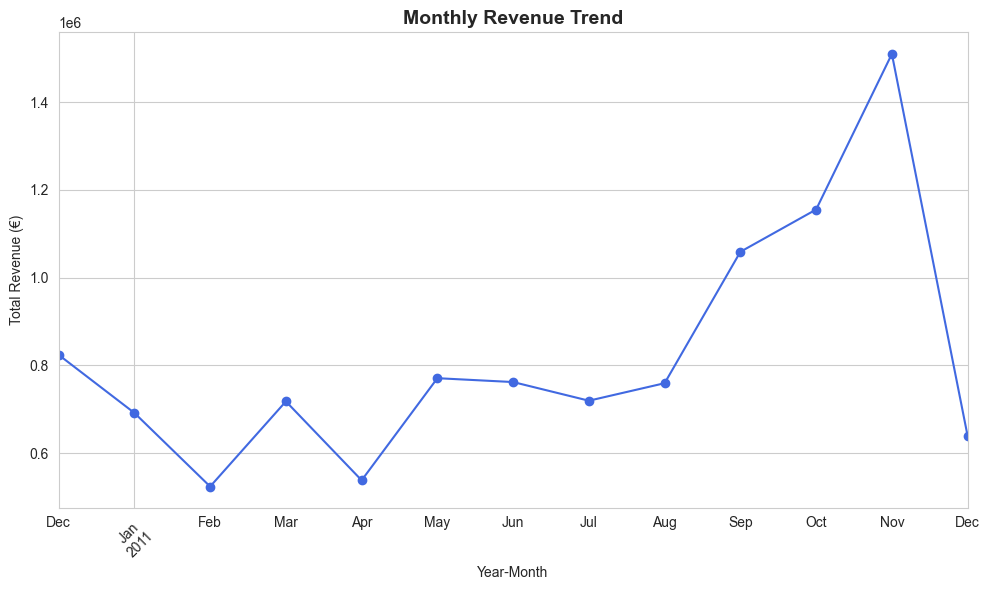

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)
plt.figure()
monthly_sales.plot(kind="line",marker="o",color="royalblue")
plt.title("Monthly Revenue Trend",fontsize=14,fontweight="bold")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Khushboo Giri\AppData\Local\Temp\ipykernel_1844\1694203408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


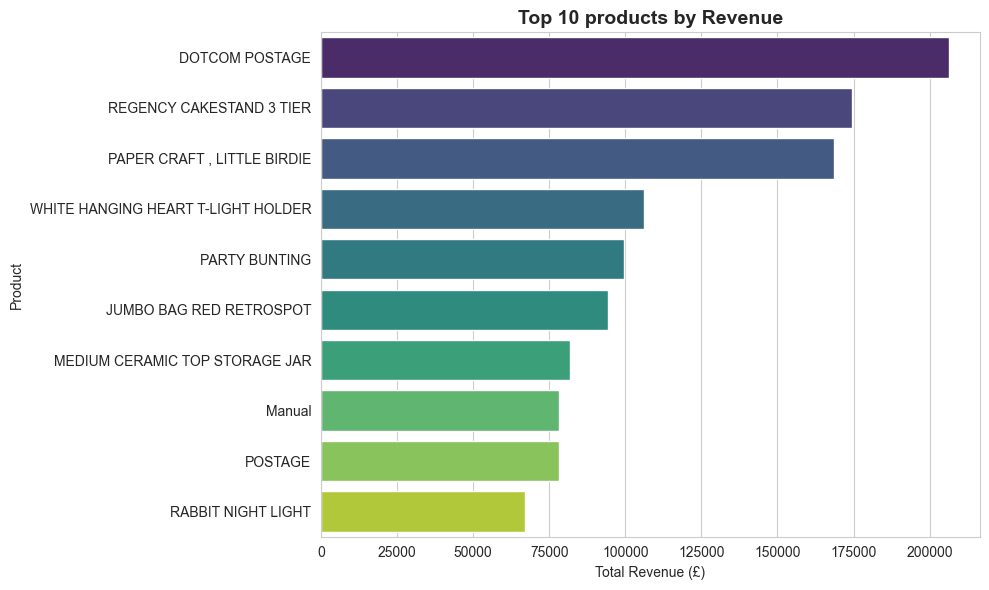

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products_revenue.values,
    y=top_products_revenue.index,
    palette="viridis"
)
plt.title("Top 10 products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Product")
           
plt.tight_layout()
plt.savefig("top_products_revenue.png", dpi=150)
plt.show()

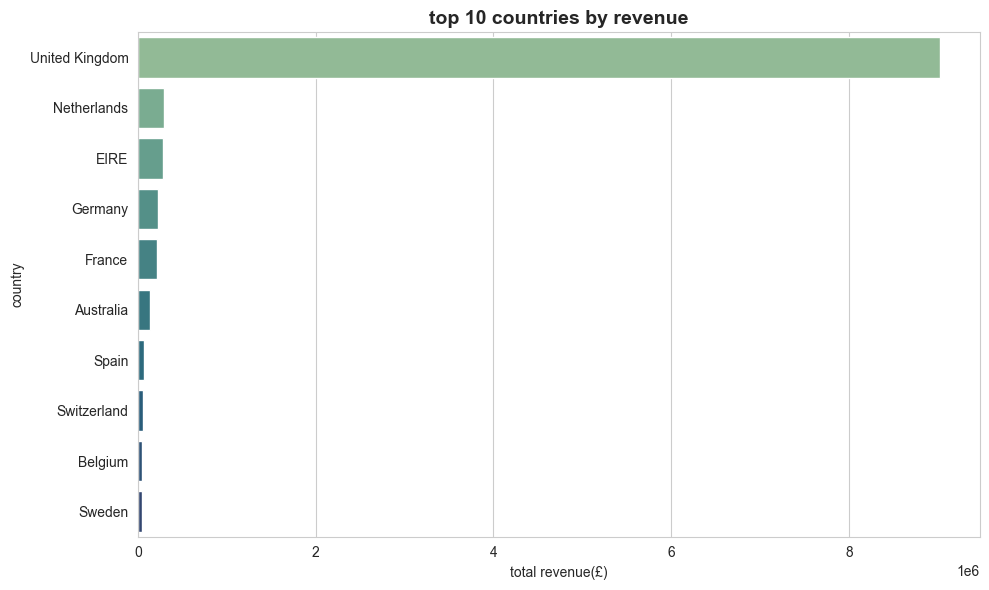

In [ ]:
plt.figure()
top_countries=country_revenue.head(10)
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="crest"
)
plt.title("top 10 countries by revenue", fontsize=14, fontweight="bold")
plt.xlabel("total revenue(£)")
plt.ylabel("country")
plt.tight_layout()
plt.savefig("revenue_by_country.png", dpi=150)
plt.show()

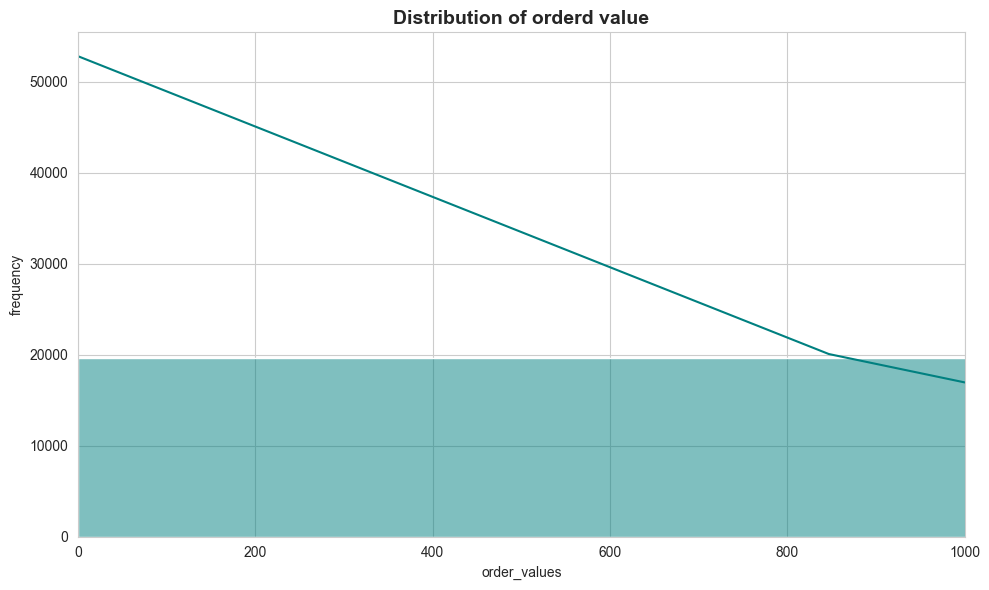

In [ ]:
#Distribution of order value (histogram+KDE)

plt.figure()
sns.histplot(order_values,bins=50,kde=True,color="teal")
plt.title("Distribution of orderd value", fontsize=14,fontweight="bold")
plt.xlabel("order_values")
plt.ylabel("frequency")
plt.xlim(0,1000)
plt.tight_layout()
plt.savefig("order_values_distribution.png",dpi=150)
plt.show()

C:\Users\Khushboo Giri\AppData\Local\Temp\ipykernel_1844\3731964779.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


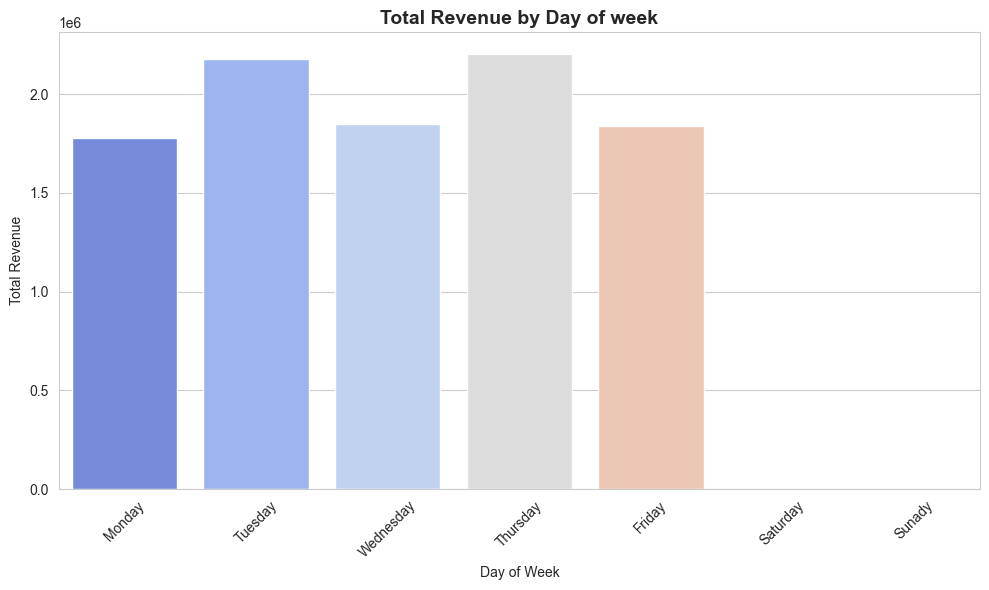

In [ ]:
# Sales by Day of week(Bar Chart)

day_order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunady"]
sales_by_day=(
    df_clean.groupby("DayOfWeek")["TotalPrice"]
    .sum()
    .reindex(day_order)
)
plt.figure()
sns.barplot(
    x=sales_by_day.index,
    y=sales_by_day.values,
    palette="coolwarm"
)
plt.title("Total Revenue by Day of week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Sales by day of week.png",dpi=150)
plt.show()


In [66]:
obj=pd.Series([10,20,30], index=[
    "a","b","c"])
print("original data")
print(obj)

original data
a    10
b    20
c    30
dtype: int64


In [67]:
new_obj=obj.reindex(["c","d","a","b"], fill_value=0)
print(new_obj)

c    30
d     0
a    10
b    20
dtype: int64


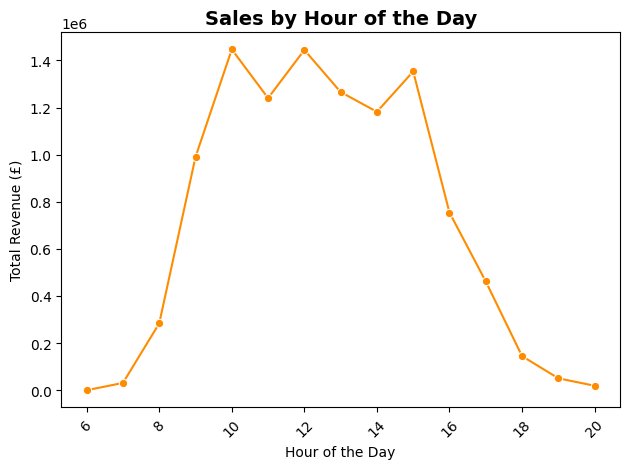

In [68]:
#7.Sales by Hour of the Day (Line chart)
sales_by_hour = df_clean.groupby("Hour")["TotalPrice"].sum()
plt.figure()
sns.lineplot(x=sales_by_hour.index, y=sales_by_hour.values, marker='o', color='darkorange')
plt.title("Sales by Hour of the Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour of the Day")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_by_hour_of_day.png", dpi=150)
plt.show()

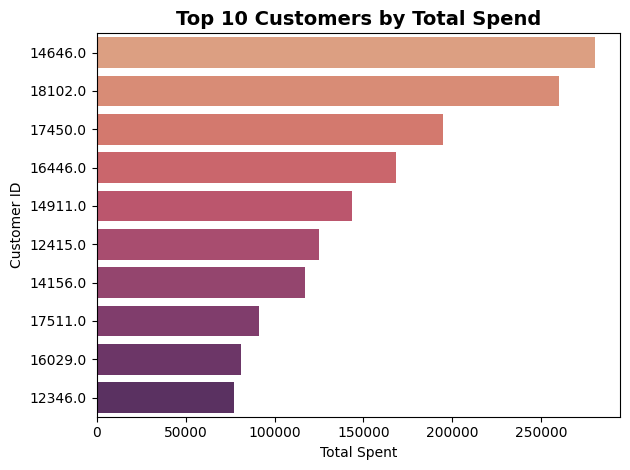

In [69]:
# Top 10 Customers by Total Spend (Bar Chart)

top_customers= customer_summary.head(10)

plt.figure()

sns.barplot(

x=top_customers ["TotalSpent"].values,

y=top_customers.index.astype(str),

hue=top_customers.index.astype(str),

palette="flare"
 
) 
plt.title("Top 10 Customers by Total Spend", fontsize=14, fontweight="bold")

plt.xlabel("Total Spent")

plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig("top_customers.png", dpi=150)
plt.show()

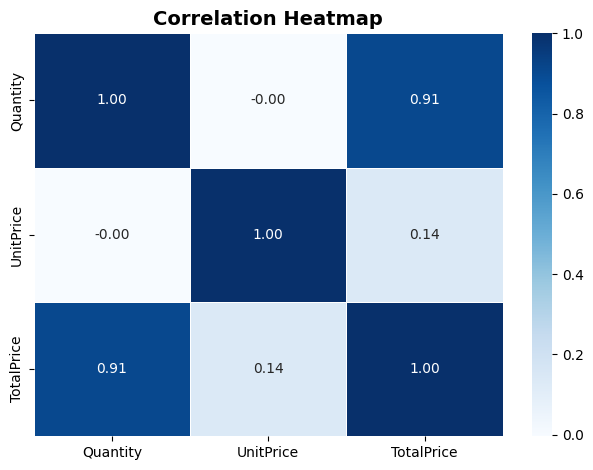

STEP 12: All visualizations created and saved as PNG files.


In [70]:
plt.figure()

corr= df_clean [["Quantity", "UnitPrice", "TotalPrice"]].corr()

sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=150)

plt.show()

print("STEP 12: All visualizations created and saved as PNG files.")

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [72]:
# Prepare the dataset for modeling
# Goal: Predict 'TotalSpent' using 'NumOrders' and 'AvgOrderValue' as features

ml_data = customer_summary[["NumOrders", "AvgOrderValue", "TotalSpent"]].dropna()

# Define independent variables (features, X) and dependent variable (target, y)
X = ml_data[["NumOrders", "AvgOrderValue"]]
y = ml_data["TotalSpent"]

print("Feature set shape:", X.shape)
print("Target shape:", y.shape)

Feature set shape: (4338, 2)
Target shape: (4338,)


In [73]:
# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3470
Testing samples: 868


In [74]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed.")
print("Intercept:", model.intercept_)
print("Coefficients (NumOrders, AvgOrderValue):", model.coef_)

Model training completed.
Intercept: -866.0268982425914
Coefficients (NumOrders, AvgOrderValue): [663.12854199   1.75090119]


In [75]:
# Predict Total Spending on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R-squared (R2 Score):", round(r2, 4))

Model Evaluation Metrics
Mean Absolute Error (MAE): 1259.25
Mean Squared Error (MSE): 11190136.49
Root Mean Squared Error (RMSE): 3345.17
R-squared (R2 Score): 0.6288


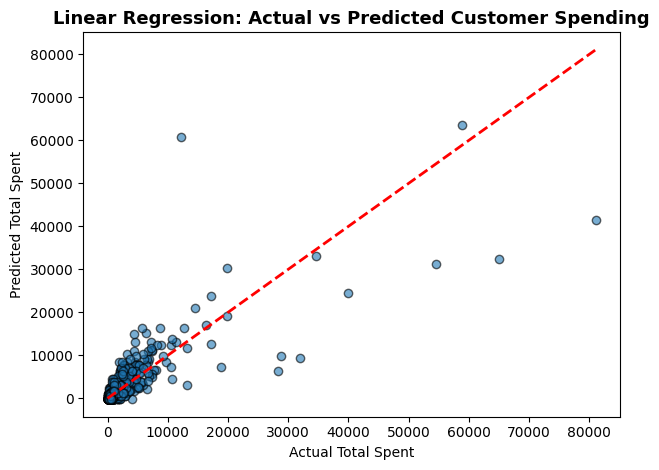

In [76]:
# Visualize Actual vs Predicted Total Spending
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", linewidth=2)
plt.xlabel("Actual Total Spent")
plt.ylabel("Predicted Total Spent")
plt.title("Linear Regression: Actual vs Predicted Customer Spending", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("linear_regression_actual_vs_predicted.png", dpi=150)
plt.show()